# Week 6 (07-20-2026)

## Outlier Analysis: The High-Mass End of the $M_{\rm BH}$–$\sigma_\star$ Relation

We have now built an updated dataset combining the McConnell & Ma (2013) sample of 73 galaxies with ~20 new dynamical BH mass measurements of $\log(M_{\rm BH}/M_\odot) > 9$, compiled from the literature. 

You have also refit the $M_{\rm BH}$–$\sigma_\star$ relation for the full updated sample and for early-type galaxies separately.

 Now we want to know: **which galaxies deviate most from the best-fit relation, and what can we learn from them?**

This is an important question at the high-mass end specifically. The scatter in the $M_{\rm BH}$–$\sigma_\star$ relation is largest for the most massive galaxies, and several of the most extreme systems -- NGC 4889, Holm 15A, 4C+37.11 -- have disputed or highly uncertain BH masses. Understanding *why* some galaxies are outliers, whether it is physical or observational, is one of the open questions in the field.

---

## Goals for this analysis

1. Compute residuals from the best-fit $M_{\rm BH}$–$\sigma_\star$ relation
2. Identify outliers using a quantitative threshold
3. Visualize the residuals and flag the outliers on the $M_{\rm BH}$–$\sigma_\star$ diagram
4. Characterize the outliers: do they share morphological type, measurement method, or position in $\sigma$?
5. Investigate two outliers in the literature and write up what you find
6. Discuss what the outliers tell us about the high-mass end of the relation

---

## Before you start

This notebook picks up directly from your updated dataset and fits. Make sure the following variables are available before running any cell here — either re-run your previous notebook first, or copy the relevant arrays into the setup cell below:

- `log_sigma_full` — $\log_{10}(\sigma / \rm{km\ s}^{-1})$ for the full combined sample
- `log_mbh_full` — $\log_{10}(\rm{M}_{\rm BH} / \rm{M}_\odot)$ for the full combined sample
- `names` — galaxy names
- `morph` — morphological types
- `source` — source label for each galaxy (`'MM13'`, `'MM13_updated'`, or `'New'`)
- `slope`, `intercept` — from your best-fit linear regression on the full combined sample

Run a quick print check in the cell below to confirm everything is loaded.

In [1]:
# Setup: imports and quick check that all arrays are available
# Add any additional imports you need here

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

In [2]:
df=pd.read_csv("MBH_table_final.csv")
log_sigma_full=np.log10(df["sigma"]/200)
log_mbh_full=np.log10(df["M_BH"])
slope, intercept=np.polyfit(log_sigma_full,log_mbh_full,1)
df


,Galaxy,M_BH,M_BH_lower,M_BH_upper,sigma,Morph,Method,Source,Paper reference,MASSIVE?,BCG?,Limits source (for filled rows only)
0,A1836,3900000000,3300000000,4300000000,288.0,E,gas,MM13,NaN,NaN,NaN,NaN
1,A3565,1400000000,1200000000,1700000000,322.0,E,gas,MM13,NaN,NaN,NaN,NaN
2,CIRC,1700000,1400000,2100000,158.0,S,maser,MM13,NaN,NaN,NaN,NaN
3,IC1459,2800000000,1600000000,3900000000,315.0,E,star,MM13,NaN,NaN,NaN,NaN
4,MW,4100000,3500000,4700000,103.0,S,star,MM13,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
87,NGC4751,1400000000,1300000000,1500000000,355.4,E/S0,star,New,Rusli+13,NaN,NaN,NaN
88,NGC6861,2000000000,1800000000,2200000000,388.8,E/S0,star,New,Rustli+13,NaN,NaN,NaN
89,NGC5419,10000000000,9200000000,10800000000,350.0,E,star tri,New,Neureiter+23,NaN,NaN,NaN
90,NGC 3258,2200000000,2000000000,2400000000,232.0,E,star axi,New,Waters+24,NaN,NaN,NaN


In [3]:
# Quick check — this should print the number of galaxies in your combined sample
# and the slope and intercept of your best-fit relation.
# If you get a NameError, re-run your previous notebook first.

print(f"Combined sample size: {len(log_sigma_full)}")
print(f"Best-fit slope:     {slope:.3f}")
print(f"Best-fit intercept: {intercept:.3f}")

Combined sample size: 92
Best-fit slope:     5.747
Best-fit intercept: 8.376


---

## Part 1: Computing residuals

### What is a residual?

The **residual** for a galaxy is the difference between its measured BH mass and the BH mass the best-fit relation *predicts* for a galaxy with that velocity dispersion:

$$\Delta \log M_{\rm BH} = \log M_{\rm BH}^{\rm measured} - \log M_{\rm BH}^{\rm predicted}$$

where $\log M_{\rm BH}^{\rm predicted} = \alpha \cdot \log \sigma_\star + \beta$ comes from your linear fit.

- A **positive** residual means the galaxy has an **over-massive** BH for its velocity dispersion — it sits above the relation.
- A **negative** residual means the BH is **under-massive** — the galaxy sits below the relation.

The rms scatter of the residuals tells you how tight the relation is overall. McConnell & Ma (2013) report an rms scatter of **0.38 dex** for their full sample. You will compute the scatter for your updated sample and compare.

### (a) Compute the predicted BH masses and residuals

Using your best-fit slope and intercept, compute:
1. The predicted log MBH for every galaxy in the combined sample
2. The residual for every galaxy
3. The rms scatter (standard deviation of the residuals)

Print the rms scatter and compare it to the McConnell & Ma (2013) value of 0.38 dex. Did it go up or down after adding the new high-mass galaxies? Why might that be?

In [4]:
log_MBH_predicted=slope*log_sigma_full+intercept
delta_log_MBH=log_mbh_full-log_MBH_predicted
rms=np.std(delta_log_MBH)
rms

0.46844712996999505

*Write your answer about the rms scatter here.*

---

### (b) Define the outlier threshold and identify outliers

We define an outlier as any galaxy whose residual is more than **2 × rms** away from zero:

$$|\Delta \log M_{\rm BH}| > 2 \times \sigma_{\rm rms}$$

This is a standard convention — it flags roughly the most deviant ~5% of a normal distribution.

Create a boolean mask called `outlier_mask` that is `True` for outliers and `False` for the rest. Then print a table of the outliers, sorted from largest to smallest residual, showing:
- Galaxy name
- Residual in dex
- Measured log MBH
- log σ
- Morphological type
- Source label (MM13, Updated, or New)

> 💡 **Tip:** `np.where(outlier_mask)[0]` gives you the indices of the outliers. You can sort them by residual using `np.argsort()`.

In [10]:
outlier_mask=abs(delta_log_MBH)>2*rms
columns=["Galaxy","Residual(dex)","Measured log MBH","log σ","Morphological type","Source label"]
outliers=pd.DataFrame([df["Galaxy"],delta_log_MBH,log_mbh_full,log_sigma_full,df["Morph"],df["Source"]],columns).T
#Aquí lo hice mal, debí ingresar como dicts, pero al trasponer se arregla.
outliers=outliers[outlier_mask]
indices=np.argsort(outliers["Residual(dex)"])[::-1]
outliers=outliers.iloc[indices]
outliers

,Galaxy,Residual(dex),Measured log MBH,log σ,Morphological type,Source label
75,NGC708,1.02039,9.953276,0.09691,E,New
78,NGC997,0.959456,9.515874,0.031408,E,New
76,NGC1600,0.95085,10.279895,0.165838,E,New
2,CIRC,-1.557064,6.230449,-0.102373,S,MM13


---

## Part 2: Visualizing the residuals

### (a) Residual plot

Make a plot of the residuals $\Delta \log M_{\rm BH}$ on the y-axis vs. $\log \sigma_\star$ on the x-axis. The plot should have:

- Normal galaxies in one color (e.g. steel blue)
- Outliers in a distinct color (e.g. tomato red), with larger markers
- Galaxy name labels next to each outlier point — you can use `ax.annotate()` for this
- A horizontal line at zero (the best-fit relation)
- Dashed horizontal lines at +2σ and −2σ to show the outlier threshold
- Labeled axes, a legend, and a title

Save the figure as `residuals.png` at 150 dpi.

> ⚠️ **If labels overlap:** Try adjusting the `xytext` offset in `ax.annotate()`, or only label the 4–5 most extreme outliers. A cluttered figure is harder to read than a clean one with fewer labels.

> 💡 **Reminder of `ax.annotate()` syntax:**
> ```python
> ax.annotate('label text', xy=(x_point, y_point),
>             xytext=(x_point + offset_x, y_point + offset_y),
>             fontsize=8)
> ```

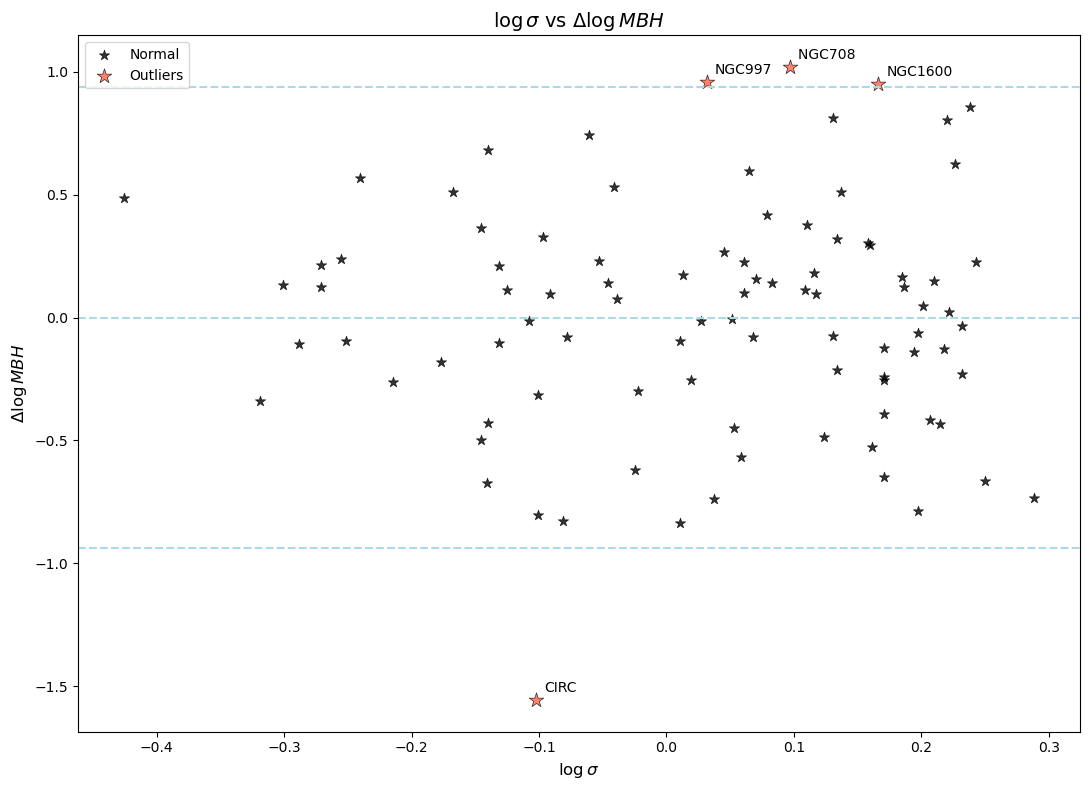

In [6]:

fig, ax = plt.subplots(figsize=(11, 8))
#ax.set_xscale("log")
#ax.set_yscale("log")
ax.set_xlabel("$\log \sigma$", fontsize=12)
ax.set_ylabel("$\Delta \log MBH$", fontsize=12)
ax.set_title("$\log \sigma$ vs $\Delta \log MBH$" , fontsize=14)


ax.scatter(log_sigma_full[~outlier_mask],delta_log_MBH[~outlier_mask],color="black", marker="*", s=60, alpha=0.8,
                   edgecolors="black", linewidths=0.5,label="Normal")
ax.scatter(log_sigma_full[outlier_mask],delta_log_MBH[outlier_mask],color="tomato", marker="*", s=120, alpha=0.8,
                   edgecolors="black", linewidths=0.5,label="Outliers")

for i,row in outliers.iterrows():
    plt.annotate(row["Galaxy"],
        (row["log σ"], row["Residual(dex)"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10 )
            
ax.axhline(y=0,linestyle="dashed",color="lightblue")
ax.axhline(y=2*rms, linestyle="dashed", color="lightblue")
ax.axhline(y=-2*rms, linestyle="dashed", color="lightblue")


ax.legend(loc="upper left", fontsize=10)
plt.tight_layout()
#plt.savefig("grafico_final.png", dpi=300, bbox_inches="tight")  
plt.show()


#print()

### (b) Two-panel figure

Now make a more complete two-panel figure. This is the version that could go on your poster.

**Top panel:** The full M–σ diagram, showing:
- All galaxies, with outliers marked in your distinct color and labeled
- The best-fit line for the full combined sample
- Shaded bands showing the 1σ and 2σ scatter regions around the fit
  - To draw a shaded band, use `ax.fill_between(x, y_lower, y_upper, alpha=0.15)`

**Bottom panel:** The residual plot from Step 2.1 (same x-axis, shared with the top panel)

To share the x-axis between the two panels, create your figure like this:
```python
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 8),
                                      sharex=True,
                                      gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.05})
```

Save the figure as `msigma_with_residuals.png` at 200 dpi.

> 💡 **Poster tip:** Font sizes should be at least 12–13 for axis labels on a poster figure. Use `fontsize=13` in your `set_xlabel`, `set_ylabel`, and `set_title` calls.

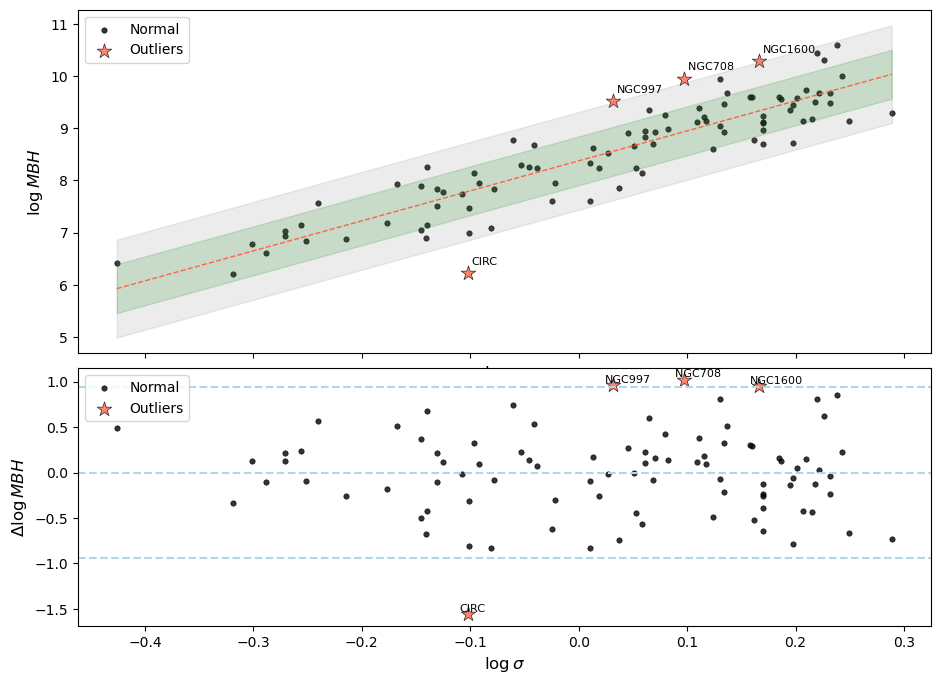

In [24]:
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 8),
                                      sharex=True,
                                      gridspec_kw={'height_ratios': [4, 3], 'hspace': 0.05})

#ax.set_xscale("log")
#ax.set_yscale("log")
ax_top.set_xlabel("$\log \sigma$", fontsize=12)
ax_top.set_ylabel("$\log MBH$", fontsize=12)

ax_top.scatter(log_sigma_full[~outlier_mask],log_mbh_full[~outlier_mask],color="black", marker=".", s=60, alpha=0.8,
                   edgecolors="black", linewidths=0.5,label="Normal")
ax_top.scatter(log_sigma_full[outlier_mask],log_mbh_full[outlier_mask],color="tomato", marker="*", s=120, alpha=0.8,
                   edgecolors="black", linewidths=0.5,label="Outliers")


x = np.linspace(log_sigma_full.min(), log_sigma_full.max(), 200)
y=slope*x+intercept
ax_top.plot(x,y,color="tomato",linestyle="dashed",linewidth=1)

ax_top.fill_between(x, y-2*rms,y+2*rms, color="grey",alpha=0.15)
ax_top.fill_between(x,y-rms,y+rms, color="green",alpha=0.15)

for i,row in outliers.iterrows():
    ax_top.annotate(row["Galaxy"],
        (row["log σ"], row["Measured log MBH"]),
        xytext=(3, 6),
        textcoords="offset points",
        fontsize=8 )



ax_top.legend(loc="upper left", fontsize=10)
#plt.tight_layout()
#plt.savefig("grafico_final.png", dpi=300, bbox_inches="tight")  



#ax.set_xscale("log")
#ax.set_yscale("log")
ax_bot.set_xlabel("$\log \sigma$", fontsize=12)
ax_bot.set_ylabel("$\Delta \log MBH$", fontsize=12)

ax_bot.scatter(log_sigma_full[~outlier_mask],delta_log_MBH[~outlier_mask],color="black", marker=".", s=60, alpha=0.8,
                   edgecolors="black", linewidths=0.5,label="Normal")
ax_bot.scatter(log_sigma_full[outlier_mask],delta_log_MBH[outlier_mask],color="tomato", marker="*", s=120, alpha=0.8,
                   edgecolors="black", linewidths=0.5,label="Outliers")

for i,row in outliers.iterrows():
    plt.annotate(row["Galaxy"],
        (row["log σ"], row["Residual(dex)"]),
        xytext=(-6, 2),
        textcoords="offset points",
        fontsize=8 )
            
ax_bot.axhline(y=0,linestyle="dashed",color="lightblue")
ax_bot.axhline(y=2*rms, linestyle="dashed", color="lightblue")
ax_bot.axhline(y=-2*rms, linestyle="dashed", color="lightblue")


ax_bot.legend(loc="upper left", fontsize=10)
plt.savefig("msigma_with_residuals.png", dpi=200)  
plt.show()


#print()

